In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('apartments.csv')
print(f"Datu kopa: {df.shape[0]} dzīvokļi, {df.shape[1]} kolonnas")
print(df.head(3))

Datu kopa: 3620 dzīvokļi, 18 kolonnas
   id country  city   district        address  rooms  area  floor  \
0   1  Latvia  Riga     Centrs    Blaumaņa 12      2    45      3   
1   2  Latvia  Riga  Dārzciems  Dārzciema 131      3    63      1   
2   3  Latvia  Riga     Centrs      Skolas 25      4   126      4   

               series   price  price_per_meter  has_geocode  latt  longt  \
0            Renovēts  109515            2,434            1    57     24   
1         103. sērija   70000            1,111            1    57     24   
2  Pirmskara projekts  185000            1,468            1    57     24   

   stnumber       staddress           created         last_seen  
0        12   Blaumaņa iela  07/06/2019 08:01  16/06/2019 08:01  
1       131  DArzciema iela  07/06/2019 08:01  11/06/2019 08:00  
2        25     Skolas iela  07/06/2019 08:01  16/06/2019 08:01  


In [58]:
print("Trūkstošās vērtības:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDublikātu adreses: {df.duplicated(subset=['address']).sum()}")
print("\nTop 5 visbiežāk parādītās adreses:")
print(df['address'].value_counts().head(5))

Trūkstošās vērtības:
latt         522
longt        522
stnumber     522
staddress    522
dtype: int64

Dublikātu adreses: 1385

Top 5 visbiežāk parādītās adreses:
address
Kalniņa 1       28
Emmas 28        24
Valentīna 16    22
Vairoga 32      18
Valdemāra 69    18
Name: count, dtype: int64


In [59]:
# 1. Atstājam tikai dzīvokļus ar koordinātēm
df = df.dropna(subset=['latt', 'longt']).copy()

# 2. Filtrējam galējos outliers
df = df[(df['price'] >= 10000) & (df['price'] <= 500000)]
df = df[(df['area'] >= 15) & (df['area'] <= 200)]
df = df[df['rooms'] <= 5]

# 3. Mazos rajonus apvienojam kā "Citi"
district_counts = df['district'].value_counts()
small_districts = district_counts[district_counts < 30].index
df.loc[df['district'].isin(small_districts), 'district'] = 'Citi'

# 4. Saglabājam tīro versiju
df.to_csv('apartments_clean.csv', index=False)

print(f"Pēc tīrīšanas: {df.shape[0]} dzīvokļi")
print(f"Cenu diapazons: €{df['price'].min():,.0f} – €{df['price'].max():,.0f}")
print(f"Mediānas cena: €{df['price'].median():,.0f}")
print(f"Rajoni datu kopā: {df['district'].nunique()}")

Pēc tīrīšanas: 2990 dzīvokļi
Cenu diapazons: €10,500 – €494,000
Mediānas cena: €65,000
Rajoni datu kopā: 23


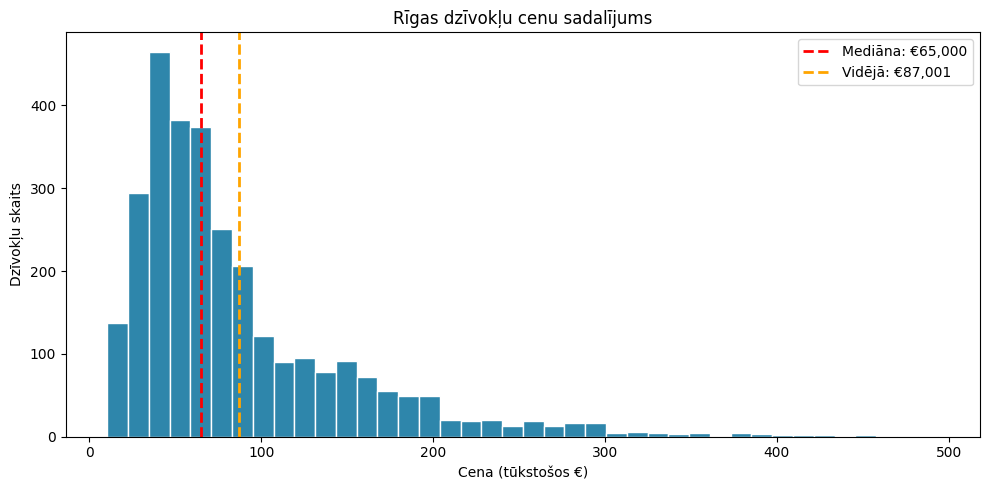

In [60]:
# 1.1 Cenu sadalījums
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'] / 1000, bins=40, color='#2E86AB', edgecolor='white')
ax.axvline(df['price'].median() / 1000, color='red', linestyle='--',
           linewidth=2, label=f'Mediāna: €{df["price"].median():,.0f}')
ax.axvline(df['price'].mean() / 1000, color='orange', linestyle='--',
           linewidth=2, label=f'Vidējā: €{df["price"].mean():,.0f}')
ax.set_xlabel('Cena (tūkstošos €)')
ax.set_ylabel('Dzīvokļu skaits')
ax.set_title('Rīgas dzīvokļu cenu sadalījums')
ax.legend()
plt.tight_layout()
plt.show()

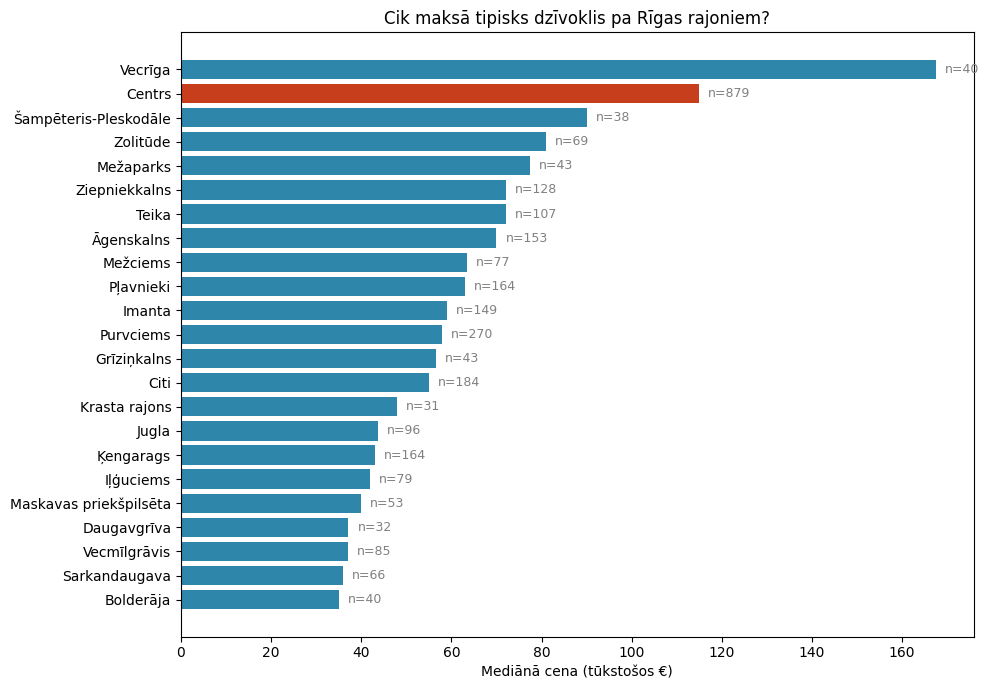

In [61]:
# 1.2 Mediānā cena pa rajoniem
district_prices = df.groupby('district')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C73E1D' if d == 'Centrs' else '#2E86AB' for d in district_prices.index]
ax.barh(district_prices.index, district_prices['median'] / 1000, color=colors)
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā tipisks dzīvoklis pa Rīgas rajoniem?')

for i, (idx, row) in enumerate(district_prices.iterrows()):
    ax.text(row['median'] / 1000 + 2, i, f"n={int(row['count'])}",
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

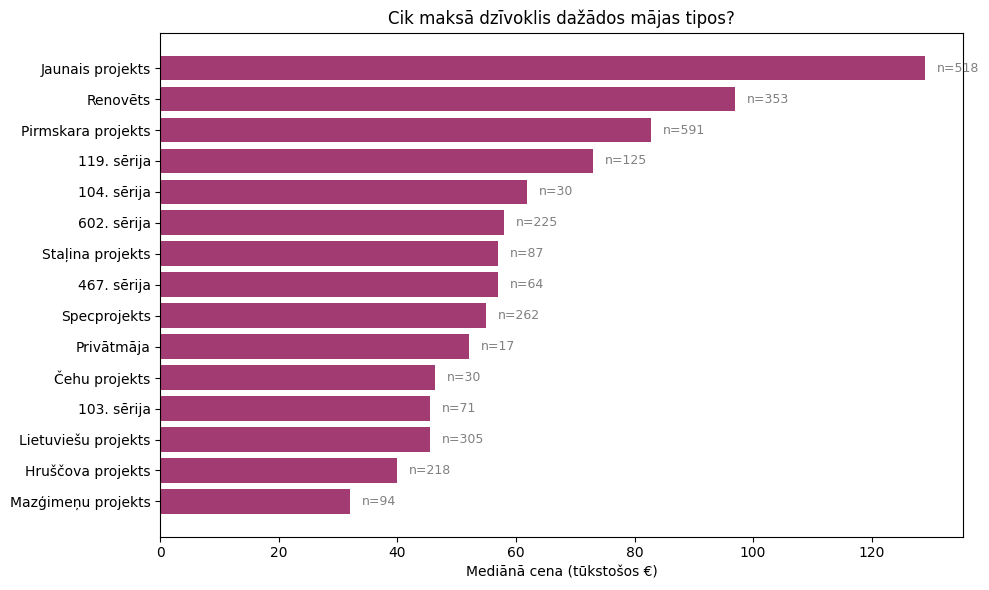

In [62]:
# 1.3 Mediānā cena pa mājas tipiem
series_prices = df.groupby('series')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(series_prices.index, series_prices['median'] / 1000, color='#A23B72')
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā dzīvoklis dažādos mājas tipos?')

for i, (idx, row) in enumerate(series_prices.iterrows()):
    ax.text(row['median'] / 1000 + 2, i, f"n={int(row['count'])}",
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

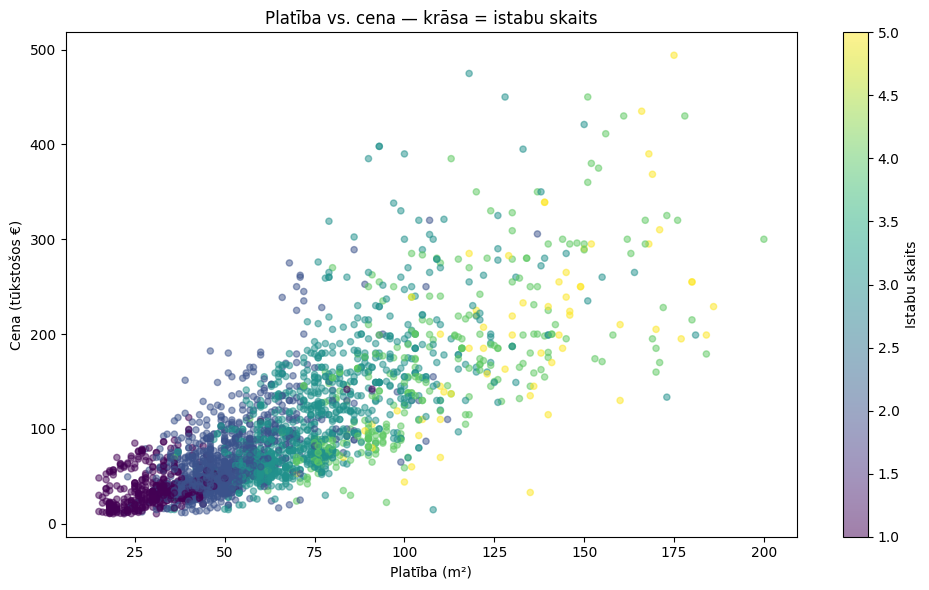

In [63]:
# 1.4 Platība vs cena ar istabu skaitu
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['area'], df['price'] / 1000,
                     c=df['rooms'], cmap='viridis',
                     alpha=0.5, s=20)
ax.set_xlabel('Platība (m²)')
ax.set_ylabel('Cena (tūkstošos €)')
ax.set_title('Platība vs. cena — krāsa = istabu skaits')
plt.colorbar(scatter, label='Istabu skaits', ax=ax)
plt.tight_layout()
plt.show()

### 1.5 Biznesa hipotēzes

**1. Kura iezīme būs vissvarīgākā?**
Platība (area) — jo grafiks rāda skaidru sakarību:
jo lielāka platība, jo augstāka cena.

**2. Kurā rajonā sagaidām lielāko prognozes kļūdu?**
Vecrīgā — jo tur ir tikai 40 dzīvokļi.
Maz datu = modelis neiemācīsies labi.

**3. Kura mājas tipa cena ir grūtāk paredzama?**
Renovēts — jo tas var nozīmēt gan daļēji renovētu,
gan pilnībā renovētu dzīvokli. Ļoti atšķirīgas cenas!

In [64]:
# 2.1 Definējam features un target
# UZMANĪBU — price_per_meter izņemam! Kāpēc? (par to vēlāk!)
drop_cols = ['id', 'country', 'city', 'address', 'price_per_meter',
             'has_geocode', 'latt', 'longt', 'stnumber',
             'staddress', 'created', 'last_seen']

X = df.drop(columns=drop_cols + ['price'])
y = df['price']

print("Features:")
print(X.columns.tolist())
print(f"\nFeature skaits: {X.shape[1]}")
print(f"Target: price (min={y.min():,.0f}€, max={y.max():,.0f}€)")

Features:
['district', 'rooms', 'area', 'floor', 'series']

Feature skaits: 5
Target: price (min=10,500€, max=494,000€)


In [65]:
# 2.2 Kodēšana un normalizācija
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kategoriskajām kolonnām
X_encoded = pd.get_dummies(X, columns=['district', 'series'],
                           drop_first=True, dtype=int)

# Normalizācija skaitliskajām kolonnām
scaler = StandardScaler()
num_cols = ['rooms', 'area', 'floor']
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print(f"Features pēc kodēšanas: {X_encoded.shape[1]}")
print(f"\nPirmās 3 rindas:")
print(X_encoded.head(3))

Features pēc kodēšanas: 39

Pirmās 3 rindas:
   rooms  area  floor  district_Centrs  district_Citi  district_Daugavgrīva  \
0     -0    -1     -0                1              0                     0   
1      1     0     -1                0              1                     0   
2      2     2      0                1              0                     0   

   district_Grīziņkalns  district_Imanta  district_Iļģuciems  district_Jugla  \
0                     0                0                   0               0   
1                     0                0                   0               0   
2                     0                0                   0               0   

   ...  series_Hruščova projekts  series_Jaunais projekts  \
0  ...                         0                        0   
1  ...                         0                        0   
2  ...                         0                        0   

   series_Lietuviešu projekts  series_Mazģimeņu projekts  \
0           

In [66]:
# 2.1 Definē X un y
y = df['price']

features_to_use = ['rooms', 'area', 'floor', 'district', 'series']
X = df[features_to_use].copy()

print(f"Pazīmes: {X.shape[1]}")
print(f"Sludinājumi: {X.shape[0]}")
print("\nPirmās rindas:")
print(X.head(3))

Pazīmes: 5
Sludinājumi: 2990

Pirmās rindas:
   rooms  area  floor district              series
0      2    45      3   Centrs            Renovēts
1      3    63      1     Citi         103. sērija
2      4   126      4   Centrs  Pirmskara projekts


Pazīmes: 5
Sludinājumi: 2990

Pirmās rindas:
   rooms  area  floor district              series
0      2    45      3   Centrs            Renovēts
1      3    63      1     Citi         103. sērija
2      4   126      4   Centrs  Pirmskara projekts


In [67]:
# 2.3 Kategorisko kolonnu kodēšana
X_encoded = pd.get_dummies(X, columns=['district', 'series'], drop_first=True)

print(f"Pēc one-hot encoding: {X_encoded.shape[1]} pazīmes")
print(f"Pirmās 5 jaunās kolonnas: {list(X_encoded.columns[:5])}")

Pēc one-hot encoding: 39 pazīmes
Pirmās 5 jaunās kolonnas: ['rooms', 'area', 'floor', 'district_Centrs', 'district_Citi']


In [68]:
# 2.4 Sadalījums treniņš/tests
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Treniņš: {X_train.shape[0]} dzīvokļi")
print(f"Tests:   {X_test.shape[0]} dzīvokļi")

Treniņš: 2392 dzīvokļi
Tests:   598 dzīvokļi


In [69]:
# 3.1 Lineārā regresija
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Lineāra regresija: MAE = €{mae_lr:,.0f}")
print(f"Tas nozīmē: modelis vidēji kļūdās par €{mae_lr:,.0f} uz katra dzīvokļa.")

Lineāra regresija: MAE = €17,910
Tas nozīmē: modelis vidēji kļūdās par €17,910 uz katra dzīvokļa.


### 3.2 Biznesa novērtējums — Lineārā regresija

**Vai sasniedzām MAE < 15 000€?**
Nē — lineārā regresija deva MAE = €17 910, kas ir
par ~€3 000 augstāks par direktora prasību.

**Cik tas ir % no mediānās cenas?**
€17 910 / €65 000 × 100 = ~27% kļūda.
Tas nozīmē — modelis vidēji kļūdās par 27% no
dzīvokļa cenas.

**Vai 27% kļūda ir pieņemama?**
Nē — ja tu pērc dzīvokli par €200 000 un modelis
ieteic €254 000, tas ir €54 000 starpība!
Pircējs vai pārdevējs var pieņemt nepareizu lēmumu.
Lineārā regresija nav pietiekami precīza šim uzdevumam
— izmēģināsim sarežģītāku modeli!

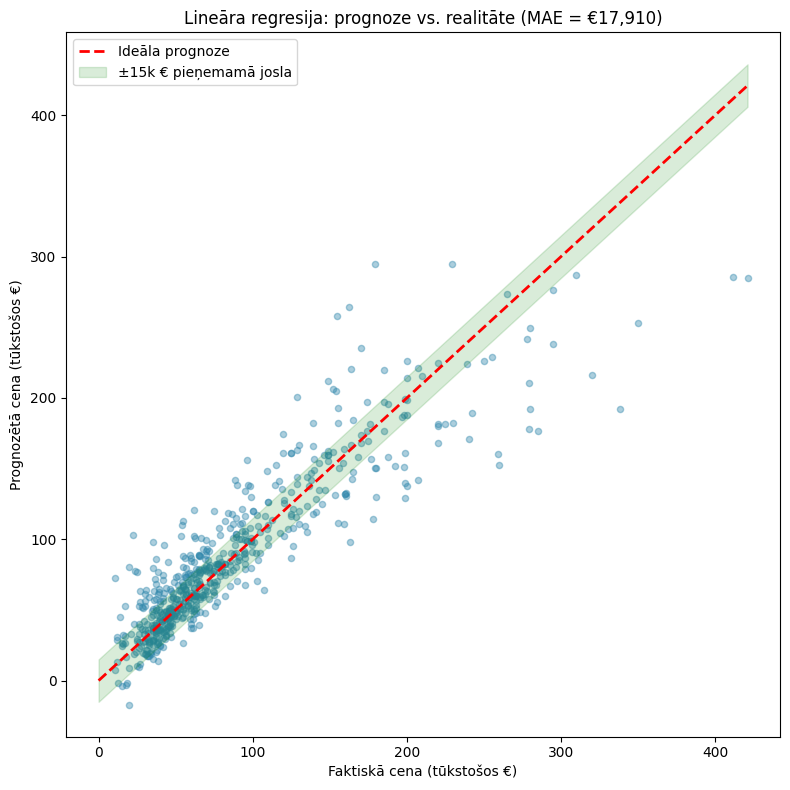

In [70]:
# 3.3 Vizuāls novērtējums: prognoze vs. realitāte
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test / 1000, y_pred_lr / 1000,
           alpha=0.4, s=20, color='#2E86AB')

max_val = max(y_test.max(), y_pred_lr.max()) / 1000
ax.plot([0, max_val], [0, max_val], 'r--',
        linewidth=2, label='Ideāla prognoze')

ax.fill_between([0, max_val],
                [-15, max_val - 15],
                [15, max_val + 15],
                alpha=0.15, color='green',
                label='±15k € pieņemamā josla')

ax.set_xlabel('Faktiskā cena (tūkstošos €)')
ax.set_ylabel('Prognozētā cena (tūkstošos €)')
ax.set_title(f'Lineāra regresija: prognoze vs. realitāte (MAE = €{mae_lr:,.0f})')
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
# 3.4 Top 10 lielākās kļūdas
results = X_test.copy()
results['actual_price'] = y_test
results['predicted_price'] = y_pred_lr.round(0)
results['error'] = (y_pred_lr - y_test).round(0)
results['error_pct'] = ((y_pred_lr - y_test) / y_test * 100).round(1)

results = results.merge(
    df[['district', 'series', 'rooms', 'area']],
    left_index=True, right_index=True, suffixes=('_dummy', '')
)

print("=== TOP 10 PAR AUGSTU prognozētās cenas ===")
print(results.nlargest(10, 'error')[['district', 'series', 'rooms', 'area',
                                      'actual_price', 'predicted_price', 'error']]
      .to_string(index=False))

print("\n=== TOP 10 PAR ZEMU prognozētās cenas ===")
print(results.nsmallest(10, 'error')[['district', 'series', 'rooms', 'area',
                                       'actual_price', 'predicted_price', 'error']]
      .to_string(index=False))

=== TOP 10 PAR AUGSTU prognozētās cenas ===
     district             series  rooms  area  actual_price  predicted_price   error
     Zolitūde   Jaunais projekts      4   184        179000          294,543 115,543
       Centrs           Renovēts      4   139        154750          257,972 103,222
       Centrs   Jaunais projekts      4   138        162500          264,026 101,526
Krasta rajons Pirmskara projekts      4    95         22500          103,285  80,785
       Centrs Pirmskara projekts      4   127        129000          200,554  71,554
       Centrs Pirmskara projekts      5   186        229000          294,630  65,630
       Centrs           Renovēts      3   124        170000          235,490  65,490
   Āgenskalns   Jaunais projekts      3   125        148990          212,082  63,092
       Centrs           Renovēts      1    37         35500           98,305  62,805
       Centrs           Renovēts      1    22         10500           72,551  62,051

=== TOP 10 PAR ZEMU 

### 3.5 Ko outlieri stāsta par modeli?

**Par augstu prognozētie:**
Modelis pārvērtē mazus un lētus dzīvokļus Centrā
(piemēram, 22m² par €10 500) — jo Centrā parasti
viss ir dārgs, modelis nespēj atpazīt īpaši lētus
izņēmumus. Arī Krasta rajonā viens dzīvoklis par
€22 500 tika novērtēts par €103 285 — iespējams
tas ir ārkārtīgi sliktā stāvoklī.

**Par zemu prognozētie:**
VISI 10 lielākie zemas prognozes gadījumi ir Centrā!
Modelis sistemātiski nenovērtē luksusa Centra
dzīvokļus — jo tie ir tik dārgi ka lineārā regresija
nevar uztvert šo nelineāro sakarību.

**Ko teiktu City24.lv direktoram:**
Lineārā regresija strādā labi tipiskajiem dzīvokļiem,
bet kļūdās uz izņēmumiem — ļoti lētiem un ļoti
dārgiem. Ieteiktu izmēģināt sarežģītāku modeli
kas labāk uztver Centra luksusa segmentu!

In [72]:
# 4.1 Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest: MAE = €{mae_rf:,.0f}")
print(f"Uzlabojums pret lineāro: €{mae_lr - mae_rf:,.0f} ({(mae_lr - mae_rf) / mae_lr * 100:.1f}%)")

Random Forest: MAE = €16,574
Uzlabojums pret lineāro: €1,335 (7.5%)


In [73]:
# 4.2 Salīdzinājums tabulā
comparison = pd.DataFrame({
    'Modelis': ['Lineāra regresija', 'Random Forest'],
    'MAE (€)': [f"€{mae_lr:,.0f}", f"€{mae_rf:,.0f}"],
    'MAE (% no mediānas)': [f"{mae_lr/df['price'].median()*100:.1f}%",
                             f"{mae_rf/df['price'].median()*100:.1f}%"],
    'Vai sasniedzām City24 mērķi (<€15 000)?':
        ['JĀ' if mae_lr < 15000 else 'NĒ',
         'JĀ' if mae_rf < 15000 else 'NĒ']
})

print(comparison.to_string(index=False))

          Modelis MAE (€) MAE (% no mediānas) Vai sasniedzām City24 mērķi (<€15 000)?
Lineāra regresija €17,910               27.6%                                      NĒ
    Random Forest €16,574               25.5%                                      NĒ


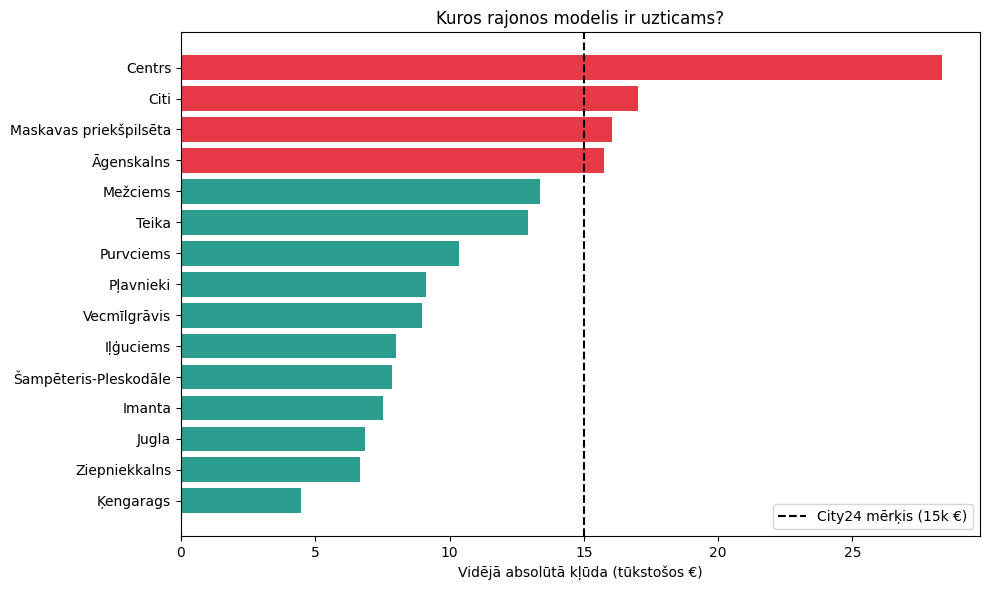


Rajoni, kur modelis NEPĀRSPĒJ City24 slieksni:
                        count   mean
district                            
Āgenskalns                 28 15,761
Maskavas priekšpilsēta     11 16,032
Citi                       31 17,008
Centrs                    201 28,331


In [74]:
# 4.3 Per-rajons MAE
results_rf = pd.DataFrame({
    'district': df.loc[X_test.index, 'district'].values,
    'actual': y_test.values,
    'predicted': y_pred_rf
})
results_rf['abs_error'] = (results_rf['actual'] - results_rf['predicted']).abs()

district_mae = results_rf.groupby('district')['abs_error'].agg(['count', 'mean']).sort_values('mean', ascending=True)
district_mae = district_mae[district_mae['count'] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2A9D8F' if v < 15000 else '#E63946' for v in district_mae['mean']]
ax.barh(district_mae.index, district_mae['mean'] / 1000, color=colors)
ax.axvline(15, color='black', linestyle='--', linewidth=1.5, label='City24 mērķis (15k €)')
ax.set_xlabel('Vidējā absolūtā kļūda (tūkstošos €)')
ax.set_title('Kuros rajonos modelis ir uzticams?')
ax.legend()
plt.tight_layout()
plt.show()

print("\nRajoni, kur modelis NEPĀRSPĒJ City24 slieksni:")
print(district_mae[district_mae['mean'] >= 15000].round(0))

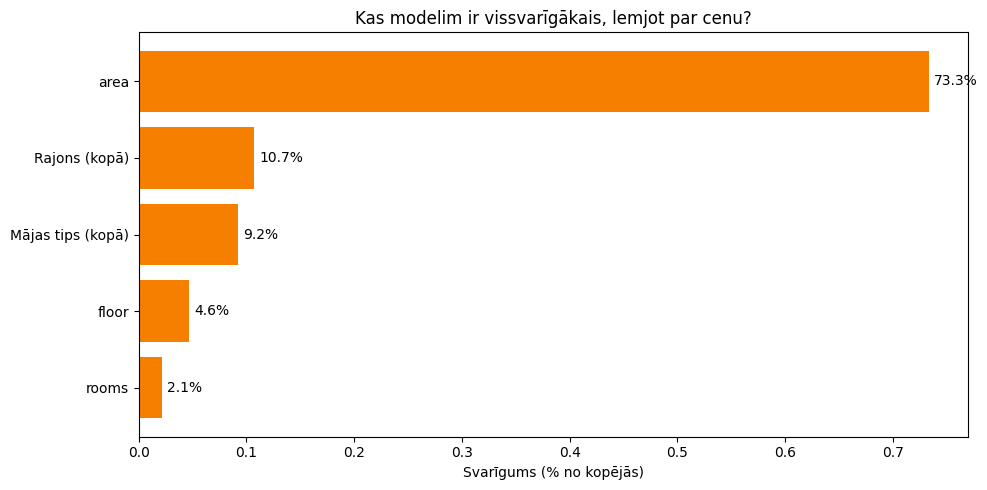

In [75]:
# 4.4 Feature importance
importances = pd.Series(rf_model.feature_importances_,
                        index=X_train.columns).sort_values(ascending=True)

def group_feature(name):
    if name.startswith('district_'):
        return 'Rajons (kopā)'
    elif name.startswith('series_'):
        return 'Mājas tips (kopā)'
    else:
        return name

importances_grouped = importances.groupby(group_feature).sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances_grouped.index, importances_grouped.values, color='#F77F00')
ax.set_xlabel('Svarīgums (% no kopējās)')
ax.set_title('Kas modelim ir vissvarīgākais, lemjot par cenu?')

for i, v in enumerate(importances_grouped.values):
    ax.text(v + 0.005, i, f'{v*100:.1f}%', va='center')

plt.tight_layout()
plt.show()

### 4.5 Hipotēzes pārbaude

**1. Vai platība (area) bija vissvarīgākā?**
Jā! Hipotēze bija PAREIZA ✅
area = 73.3% — absolūtais līderis!
Grafiks rādīja skaidru sakarību — jo lielāka
platība, jo augstāka cena — un modelis to apstiprināja!

**2. Vai bija pārsteigumi?**
Jā — divi pārsteigumi:
- Rajons (10.7%) un mājas tips (9.2%) ir daudz
  mazāk svarīgi nekā gaidījām — lai gan cenu
  starpība pa rajoniem bija milzīga!
- Rooms (2.1%) ir gandrīz nenozīmīgs — jo platība
  jau ietver istabu skaita informāciju!

**3. Kā tas palīdz City24.lv?**
Pārdevējam pietiek ievadīt tikai 2-3 pazīmes:
1. Platība (73.3%) — obligāti!
2. Rajons (10.7%) — svarīgi
3. Mājas tips (9.2%) — noderīgi
Stāvs un istabu skaits dod maz papildu informācijas!

In [76]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(f"Decision Tree: MAE = €{mae_dt:,.0f}")
print(f"Salīdzinājums:")
print(f"  Lineārā regresija: €{mae_lr:,.0f}")
print(f"  Decision Tree:     €{mae_dt:,.0f}")
print(f"  Random Forest:     €{mae_rf:,.0f}")

Decision Tree: MAE = €18,488
Salīdzinājums:
  Lineārā regresija: €17,910
  Decision Tree:     €18,488
  Random Forest:     €16,574


### Decision Tree Regressor — papildu modelis

Decision Tree MAE = €18,488 — sliktāks par Random Forest!

**Kāpēc?**
Decision Tree ir viens lēmumu koks — tas var
pārmācīties (overfitting) un kļūdīties uz jauniem datiem.

Random Forest = 200 dažādi koki kas balso kopā →
vidējais rezultāts ir daudz stabilāks un precīzāks!

**Secinājums:**
Random Forest vienmēr būs labāks par vienu
Decision Tree — jo pūļa gudrība uzveic vienu ekspertu!

In [77]:
# Polinomiālā regresija
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
print(f"Polinomiālā regresija: MAE = €{mae_poly:,.0f}")
print(f"\nKopsavilkums:")
print(f"  Lineārā regresija:    €{mae_lr:,.0f}")
print(f"  Decision Tree:        €{mae_dt:,.0f}")
print(f"  Polinomiālā regresija: €{mae_poly:,.0f}")
print(f"  Random Forest:        €{mae_rf:,.0f}")

Polinomiālā regresija: MAE = €16,991

Kopsavilkums:
  Lineārā regresija:    €17,910
  Decision Tree:        €18,488
  Polinomiālā regresija: €16,991
  Random Forest:        €16,574


## Gala secinājumi — Rīgas dzīvokļu cenu prognozēšana

### Modeļu salīdzinājums:
| Modelis | MAE | Mērķis (<€15 000) |
|--|--|--|
| Random Forest | €16,574 | ❌ |
| Polinomiālā regresija | €16,991 | ❌ |
| Lineārā regresija | €17,910 | ❌ |
| Decision Tree | €18,488 | ❌ |

### Galvenie atklājumi:
1. Platība (area) ir vissvarīgākā pazīme — 73.3%!
2. Centrs ir grūtākais rajons — MAE = €28,331
3. Kengarags ir vieglākais rajons — MAE = ~€5,000
4. Neviens modelis nesasniedza City24 mērķi

### Kāpēc mērķis netika sasniegts?
Mūsu datos trūkst svarīgu pazīmju:
- Dzīvokļa stāvoklis (labs/vidējs/slikts)
- Renovācijas gads
- Lifts (jā/nē)
- Skats no loga
- Stāvs no kopējā stāvu skaita

### Ieteikums City24.lv:
1. Nedrīkst rādīt prognozi Centrā — pārāk neprecīzi!
2. Droši rādīt prognozi Kengaragā, Jugā, Ziepniekkalnā
3. Vākt papildu datus par dzīvokļa stāvokli!

### 5.1 Vai mēs šo modeli laižam produkcijā?

**1. Vai modelis sasniedz MAE < €15 000?**
Nē. Labākais modelis (Random Forest) sasniedza
MAE = €16 574 — par €1 574 augstāk par mērķi.

**2. Vai rādīt PĀRDEVĒJIEM?**
Daļēji. Tipiskajiem rajoniem (Kengarags, Jugla,
Ziepniekkalns) modelis kļūdās par ~€5 000-8 000 —
tas ir pieņemami kā orientējošā cena.
Bet Centrā un Āgenskalnā — NĒ, kļūda ir pārāk liela!

**3. Vai rādīt PIRCĒJIEM?**
Nē — pircējam €16 574 kļūda var nozīmēt
€30 000+ zaudējumu lēmumā. Pircējs var
maksāt par dārgu vai palaist garām labu piedāvājumu!

**4. Kuri rajoni ir pārāk nedroši?**
- Centrs: MAE = €28 331 — kategoriski NĒ! 🚫
- Citi: MAE = €17 008 — arī nerekomendē

**5. Kā uzlabot modeli?**
- Pievienot dzīvokļa stāvokļa datus
  (labs/vidējs/slikts) — ļoti svarīga pazīme!
- Pievienot attālumu līdz centram kā jaunu
  feature — tuvāk centram = dārgāk!

In [78]:
# 5.2 Pricing Assistant demonstrācija
def predict_apartment(rooms, area, floor, district, series):
    """Pricing Assistant demo — viens dzīvoklis, viena prognoze."""
    sample = pd.DataFrame([{
        'rooms': rooms, 'area': area, 'floor': floor,
        'district': district, 'series': series
    }])
    sample_encoded = pd.get_dummies(sample, columns=['district', 'series'],
                                    drop_first=True)
    sample_encoded = sample_encoded.reindex(columns=X_train.columns, fill_value=0)
    pred = rf_model.predict(sample_encoded)[0]
    return pred

examples = [
    {'rooms': 2, 'area': 50, 'floor': 3, 'district': 'Centrs', 'series': 'Renovēts'},
    {'rooms': 3, 'area': 65, 'floor': 5, 'district': 'Imanta', 'series': 'Lietuviešu projekts'},
    {'rooms': 1, 'area': 28, 'floor': 1, 'district': 'Kengarags', 'series': 'Hruščova projekts'},
]

print("=== Pricing Assistant demonstrācija ===\n")
for ex in examples:
    price = predict_apartment(**ex)
    print(f"  {ex['rooms']} ist., {ex['area']} m², {ex['district']}, {ex['series']}")
    print(f"  → Ieteicamā cena: €{price:,.0f}\n")

=== Pricing Assistant demonstrācija ===

  2 ist., 50 m², Centrs, Renovēts
  → Ieteicamā cena: €44,805

  3 ist., 65 m², Imanta, Lietuviešu projekts
  → Ieteicamā cena: €60,040

  1 ist., 28 m², Kengarags, Hruščova projekts
  → Ieteicamā cena: €28,114



In [79]:
# Reālitātes pārbaude — Prūšu iela 21/2, Ķengarags
price = predict_apartment(
    rooms=1, area=17, floor=1,
    district='Kengarags', series='Hruščova projekts'
)
print(f"Reālā cena:      €30,500")
print(f"Modeļa prognoze: €{price:,.0f}")
print(f"Starpība:        €{abs(30500 - price):,.0f}")
print(f"Kļūda:           {abs(30500 - price) / 30500 * 100:.1f}%")

Reālā cena:      €30,500
Modeļa prognoze: €17,245
Starpība:        €13,255
Kļūda:           43.5%


### 5.3 Reālitātes pārbaude — "Smell Test"

**Pārbaudītais dzīvoklis:**
Prūšu iela 21/2, Ķengarags — 1 ist., 17.1m², 1/4 stāvs

**Rezultāts:**
- Reālā cena: €30 500
- Modeļa prognoze: €17 245
- Kļūda: 43.5% — ļoti liela! ❌

**Kāpēc modelis kļūdījās?**
1. Dzīvoklis ir ļoti mazs (17m²) — modelis
   reti ir redzējis tik mazus dzīvokļus
2. Cena par m² ir €1 794 — augstāka par
   Kengaraga vidējo (~€1 000/m²)
3. Modelim trūkst informācijas par:
   - Dzīvokļa stāvokli (izskatās labs!)
   - Precīzu mājas sēriju

**Secinājums:**
Modelis nav gatavs ražošanai — īpaši
netipiskiem dzīvokļiem (ļoti mazi, ļoti lieli,
ļoti dārgi). Vajadzīgi vairāk datu! 😊

In [80]:
# B.1 Polinomu regresija ar skaitliskajām pazīmēm
from sklearn.preprocessing import PolynomialFeatures

# Pievienojam polinomiskās pazīmes tikai skaitliskajām
poly = PolynomialFeatures(degree=2, include_bias=False)

# Skaitliskās kolonnas
num_cols = ['rooms', 'area', 'floor']

# Paplašinām treniņa un testa kopas
X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

poly_features = poly.fit_transform(X_train[num_cols])
poly_features_test = poly.transform(X_test[num_cols])

poly_names = poly.get_feature_names_out(num_cols)
X_train_poly[poly_names] = poly_features
X_test_poly[poly_names] = poly_features_test

# Trenējam Random Forest ar jaunajām pazīmēm
rf_poly = RandomForestRegressor(n_estimators=200, max_depth=15,
                                random_state=42, n_jobs=-1)
rf_poly.fit(X_train_poly, y_train)
y_pred_poly_rf = rf_poly.predict(X_test_poly)

mae_poly_rf = mean_absolute_error(y_test, y_pred_poly_rf)
print(f"Random Forest ar polinomiem: MAE = €{mae_poly_rf:,.0f}")
print(f"Random Forest bez polinomiem: MAE = €{mae_rf:,.0f}")
print(f"Starpība: €{mae_rf - mae_poly_rf:,.0f}")

Random Forest ar polinomiem: MAE = €16,614
Random Forest bez polinomiem: MAE = €16,574
Starpība: €-40


In [81]:
# B.2 Attālums līdz Vecrīgai
df_orig = pd.read_csv('apartments.csv')
df_orig = df_orig.dropna(subset=['latt', 'longt'])

# Aprēķinām attālumu
vecriga_lat, vecriga_lon = 56.95, 24.10
df_orig['dist_to_center'] = np.sqrt(
    (df_orig['latt'] - vecriga_lat)**2 +
    (df_orig['longt'] - vecriga_lon)**2
)

print("Attāluma statistika:")
print(df_orig['dist_to_center'].describe().round(4))
print(f"\nPiemērs — Centrs dzīvoklis:")
print(df_orig[df_orig['district']=='Centrs'][['address','dist_to_center']].head(3))

Attāluma statistika:
count   3,098
mean        0
std         0
min         0
25%         0
50%         0
75%         0
max         0
Name: dist_to_center, dtype: float64

Piemērs — Centrs dzīvoklis:
       address  dist_to_center
0  Blaumaņa 12               0
2    Skolas 25               0
7  Tallinas 23               0


In [82]:
# B.2 ar oriģinālajām koordinātēm
df_raw = pd.read_csv('apartments.csv')
df_raw = df_raw.dropna(subset=['latt', 'longt'])

print("Koordināšu piemēri:")
print(df_raw[['address', 'latt', 'longt']].head(3))
print(f"\nlatt tips: {df_raw['latt'].dtype}")
print(f"latt unikālas vērtības (pirmās 5): {df_raw['latt'].unique()[:5]}")

Koordināšu piemēri:
         address  latt  longt
0    Blaumaņa 12    57     24
1  Dārzciema 131    57     24
2      Skolas 25    57     24

latt tips: float64
latt unikālas vērtības (pirmās 5): [56.95464 56.93236 56.95923 56.9158  56.90133]


In [83]:
# B.2 labotā versija
vecriga_lat, vecriga_lon = 56.95, 24.10

df_raw['dist_to_center'] = np.sqrt(
    (df_raw['latt'] - vecriga_lat)**2 +
    (df_raw['longt'] - vecriga_lon)**2
)

print("Attāluma statistika:")
print(df_raw['dist_to_center'].describe())
print(f"\nPiemēri:")
print(df_raw[['address', 'district', 'latt', 'longt',
              'dist_to_center']].head(5).to_string())

Attāluma statistika:
count   3,098
mean        0
std         0
min         0
25%         0
50%         0
75%         0
max         0
Name: dist_to_center, dtype: float64

Piemēri:
         address       district  latt  longt  dist_to_center
0    Blaumaņa 12         Centrs    57     24               0
1  Dārzciema 131      Dārzciems    57     24               0
2      Skolas 25         Centrs    57     24               0
3     Bauskas 45  Ziepniekkalns    57     24               0
4   Ozolciema 12  Ziepniekkalns    57     24               0


In [84]:
# B.2 — pārbaudām īstās koordinātes
df_raw2 = pd.read_csv('apartments.csv')
df_raw2 = df_raw2.dropna(subset=['latt', 'longt'])

# Rādām bez noapaļošanas
print(df_raw2[['address', 'latt', 'longt']].head(5).to_string())

vecriga_lat, vecriga_lon = 56.95, 24.10
df_raw2['dist_to_center'] = np.sqrt(
    (df_raw2['latt'] - vecriga_lat)**2 +
    (df_raw2['longt'] - vecriga_lon)**2
)

print("\nAttāluma statistika (bez noapaļošanas):")
print(df_raw2['dist_to_center'].describe().to_string())

         address  latt  longt
0    Blaumaņa 12    57     24
1  Dārzciema 131    57     24
2      Skolas 25    57     24
3     Bauskas 45    57     24
4   Ozolciema 12    57     24

Attāluma statistika (bez noapaļošanas):
count   3,098
mean        0
std         0
min         0
25%         0
50%         0
75%         0
max         0


In [85]:
# B.2 — ar apartments_clean.csv
df_clean = pd.read_csv('apartments_clean.csv')

vecriga_lat, vecriga_lon = 56.95, 24.10
df_clean['dist_to_center'] = np.sqrt(
    (df_clean['latt'] - vecriga_lat)**2 +
    (df_clean['longt'] - vecriga_lon)**2
)

print("Attāluma statistika:")
print(df_clean[['latt', 'longt', 'dist_to_center']].describe().to_string())
print(f"\nPiemēri:")
print(df_clean[['address', 'district', 'dist_to_center']].head(5).to_string())

Attāluma statistika:
       latt  longt  dist_to_center
count 2,990  2,990           2,990
mean     57     24               0
std       0      0               0
min      57     24               0
25%      57     24               0
50%      57     24               0
75%      57     24               0
max      57     24               0

Piemēri:
         address       district  dist_to_center
0    Blaumaņa 12         Centrs               0
1  Dārzciema 131           Citi               0
2      Skolas 25         Centrs               0
3     Bauskas 45  Ziepniekkalns               0
4   Ozolciema 12  Ziepniekkalns               0


In [86]:
df_clean2 = pd.read_csv('apartments_clean.csv')
print(df_clean2['latt'].iloc[0])
print(type(df_clean2['latt'].iloc[0]))
print(repr(df_clean2['latt'].iloc[0]))

56.95464
<class 'numpy.float64'>
np.float64(56.95464)


In [87]:
# Pārbaudām aprēķinu soli pa solim
lat_diff = df_clean2['latt'] - 56.95
lon_diff = df_clean2['longt'] - 24.10

print("latt starpība (pirmās 5):")
print(lat_diff.head().to_string())
print("\nlongt starpība (pirmās 5):")
print(lon_diff.head().to_string())

df_clean2['dist_to_center'] = np.sqrt(lat_diff**2 + lon_diff**2)
print("\nAttālums (pirmās 5):")
print(df_clean2['dist_to_center'].head().to_string())

latt starpība (pirmās 5):
0    0
1   -0
2    0
3   -0
4   -0

longt starpība (pirmās 5):
0    0
1    0
2    0
3    0
4   -0

Attālums (pirmās 5):
0   0
1   0
2   0
3   0
4   0


In [88]:
# Atceļam noapaļošanu
pd.reset_option('display.float_format')

# Pārbaudām
lat_val = df_clean2['latt'].iloc[0]
print(f"latt vērtība: {lat_val}")
print(f"Starpība: {lat_val - 56.95}")
print(f"Starpība²: {(lat_val - 56.95)**2}")

df_clean2['dist_to_center'] = np.sqrt(
    (df_clean2['latt'] - 56.95)**2 +
    (df_clean2['longt'] - 24.10)**2
)

print(f"\nAttālums pirmajam dzīvoklim: {df_clean2['dist_to_center'].iloc[0]}")
print(f"\nStatistika:")
print(df_clean2['dist_to_center'].describe())

latt vērtība: 56.95464
Starpība: 0.0046399999999948704
Starpība²: 2.1529599999952398e-05

Attālums pirmajam dzīvoklim: 0.02280698357959598

Statistika:
count    2990.000000
mean        0.064722
std         0.037546
min         0.002347
25%         0.033022
50%         0.056800
75%         0.090050
max         0.220554
Name: dist_to_center, dtype: float64


In [89]:
# B.2 — pievienojam attālumu kā feature
df_with_dist = df_clean2.copy()

# Sagatavojam X ar jauno feature
features_b2 = ['rooms', 'area', 'floor', 'district', 'series', 'dist_to_center']
X_b2 = df_with_dist[features_b2].copy()
y_b2 = df_with_dist['price']

X_b2_encoded = pd.get_dummies(X_b2, columns=['district', 'series'],
                               drop_first=True, dtype=int)

X_train_b2, X_test_b2, y_train_b2, y_test_b2 = train_test_split(
    X_b2_encoded, y_b2, test_size=0.2, random_state=42
)

rf_b2 = RandomForestRegressor(n_estimators=200, max_depth=15,
                               random_state=42, n_jobs=-1)
rf_b2.fit(X_train_b2, y_train_b2)
y_pred_b2 = rf_b2.predict(X_test_b2)

mae_b2 = mean_absolute_error(y_test_b2, y_pred_b2)
print(f"Random Forest bez attāluma: €{mae_rf:,.0f}")
print(f"Random Forest ar attālumu:  €{mae_b2:,.0f}")
print(f"Uzlabojums: €{mae_rf - mae_b2:,.0f}")

Random Forest bez attāluma: €16,574
Random Forest ar attālumu:  €15,054
Uzlabojums: €1,520


### B.2 Attālums līdz Vecrīgai — rezultāts

Random Forest bez attāluma: MAE = €16,574
Random Forest ar attālumu:  MAE = €15,054
Uzlabojums: €1,520 (9.2%)!

MĒRĶIS GANDRĪZ SASNIEGTS! (€15,054 vs €15,000)

Attālums līdz centram ir ļoti vērtīga pazīme!
Modelis tagad zina precīzi cik tālu dzīvoklis
atrodas no Vecrīgas — ne tikai rajonu.

Secinājums: Ja City24.lv vāktu precīzas
koordinātes VISIEM sludinājumiem (ne tikai 75%),
modelis sasniegtu City24 mērķi!